In [ ]:
import os
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define the project root path
# You can change 'Medical_Simplifier_Project' if you prefer a different name
PROJECT_ROOT = "/content/drive/MyDrive/Medical_Simplifier_Project"

# 3. Define the subdirectories we need
folders = [
    "data/raw",
    "data/processed",
    "models/adapter_model",
    "scripts",
    "logs"
]

def create_folders(root, folder_list):
    """Creates the project folder structure automatically."""
    if not os.path.exists(root):
        os.makedirs(root)
        print(f"[INFO] Created root directory: {root}")

    for folder in folder_list:
        path = os.path.join(root, folder)
        if not os.path.exists(path):
            os.makedirs(path)
            print(f"[INFO] Created folder: {path}")
        else:
            print(f"[INFO] Folder already exists: {path}")

# Execute folder creation
create_folders(PROJECT_ROOT, folders)

Mounted at /content/drive
[INFO] Folder already exists: /content/drive/MyDrive/Medical_Simplifier_Project/data/raw
[INFO] Folder already exists: /content/drive/MyDrive/Medical_Simplifier_Project/data/processed
[INFO] Folder already exists: /content/drive/MyDrive/Medical_Simplifier_Project/models/adapter_model
[INFO] Folder already exists: /content/drive/MyDrive/Medical_Simplifier_Project/scripts
[INFO] Folder already exists: /content/drive/MyDrive/Medical_Simplifier_Project/logs


In [ ]:
# @title
config_content = f"""
import os

# Base Paths
ROOT_DIR = "{PROJECT_ROOT}"
DATA_DIR = os.path.join(ROOT_DIR, "data")
RAW_DATA_PATH = os.path.join(DATA_DIR, "raw")
PROCESSED_DATA_PATH = os.path.join(DATA_DIR, "processed")
MODEL_SAVE_DIR = os.path.join(ROOT_DIR, "models/adapter_model")

# Model Metadata
# We use a 4-bit quantized version to fit in Colab T4 RAM
BASE_MODEL_ID = "unsloth/mistral-7b-v0.3-bnb-4bit"

# Fine-tuning Hyperparameters (Optimized for T4 GPU)
LORA_R = 16
LORA_ALPHA = 32
TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj"]
BATCH_SIZE = 2
GRADIENT_ACCUMULATION_STEPS = 4
LEARNING_RATE = 2e-4
MAX_STEPS = 300  # Adjusted for Colab's time limits
"""

# Save this string as a .py file in your Drive
config_file_path = os.path.join(PROJECT_ROOT, "scripts/config.py")
with open(config_file_path, "w") as f:
    f.write(config_content.strip())

print(f"[SUCCESS] config.py created at {config_file_path}")

[SUCCESS] config.py created at /content/drive/MyDrive/Medical_Simplifier_Project/scripts/config.py


In [ ]:
pip install datasets=="4.3.0" trl=="0.24.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 16.6 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [ ]:
# The '!' allows you to run shell commands in Colab
!pip install -q -U transformers peft accelerate bitsandbytes datasets trl


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.1/825.1 kB 24.5 MB/s eta 0:00:00


In [ ]:
import os
import pandas as pd
from datasets import load_dataset
import sys
import importlib # Added for module management

# Import our config
PROJECT_ROOT = "/content/drive/MyDrive/Medical_Simplifier_Project"
scripts_path = os.path.join(PROJECT_ROOT, "scripts")

# Ensure the scripts directory is in the Python path
# Using insert(0, ...) to prioritize it
if scripts_path not in sys.path:
    sys.path.insert(0, scripts_path)

# Force a fresh import: If 'config' was previously imported (or failed),
# it might be cached. Removing it forces a fresh module search.
if "config" in sys.modules:
    del sys.modules["config"]

# Invalidate the import caches to force Python to re-scan sys.path
importlib.invalidate_caches()

import config

def format_instruction(sample):
    """
    Formats the data into a prompt that the LLM can understand.
    Input: Medical Terminology (from 'Prompt' column)
    Output: Simplified Summary + Triage Alert (from 'Completion' column)
    """
    # FIX: Use 'Prompt' and 'Completion' which are the actual column names in BI55/MedText
    medical_report = sample['Prompt']
    simplified_response = sample['Completion']

    # This is the 'Template' the model will learn
    prompt = f"""### Instruction:
Summarize the following medical report in simple terms for a non-medical person.
Clearly state if they should seek a doctor (Alert) or if the findings are normal.

### Medical Report:
{medical_report}

### Simplified Summary & Alert:
{simplified_response}"""

    return {"text": prompt}

def prepare_and_save_data():
    print("[1/3] Loading medical dataset from Hugging Face...")
    try:
        # Loading BI55/MedText
        dataset = load_dataset("BI55/MedText", split="train[:1000]")

        print("[2/3] Formatting data into Instruction-Response pairs...")
        # Map the updated formatting function
        formatted_dataset = dataset.map(format_instruction)

        # Save to Google Drive
        train_path = os.path.join(config.PROCESSED_DATA_PATH, "train_data.jsonl")
        formatted_dataset.to_json(train_path)

        print(f"[3/3] Success! Processed data saved to: {train_path}")
        return train_path

    except Exception as e:
        print(f"[ERROR] Data preparation failed: {e}")

# Run the preparation
prepare_and_save_data()

ModuleNotFoundError: No module named 'config'

In [ ]:
# Execute the function we just defined
# This will download the data and save it to your Drive 'processed' folder
prepare_and_save_data()

[1/3] Loading medical dataset from Hugging Face...
[2/3] Formatting data into Instruction-Response pairs...


Creating json from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

[3/3] Success! Processed data saved to: /content/drive/MyDrive/Medical_Simplifier_Project/data/processed/train_data.jsonl


'/content/drive/MyDrive/Medical_Simplifier_Project/data/processed/train_data.jsonl'

In [ ]:
# Unsloth is highly recommended for T4 GPUs to avoid 'Out of Memory' errors.run it manually
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps "xformers<0.0.27" "trl<0.9.0" peft accelerate bitsandbytes


ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/bin/pip3", line 10, in <module>
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/main.py", line 78, in main
    command = create_command(cmd_name, isolated=("--isolated" in cmd_args))
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/__init__.py", line 114, in create_command
    module = importlib.import_module(module_path)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/importlib/__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1331, in _find_and_load_unlocked
  

In [ ]:
import torch
major_version, minor_version = torch.cuda.get_device_capability()
# Must install separately since Colab has torch 2.9.0+cu126 default
if major_version >= 8:
    # For Ampere, Ada, or Hopper GPUs (A100, H100, L4, RTX 30xx/40xx)
    !pip install --no-deps "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
else:
    # For older GPUs (T4, V100)
    !pip install --no-deps "unsloth[colab-old] @ git+https://github.com/unslothai/unsloth.git"

# Install critical dependencies separately to avoid the xformers build error
!pip install --no-deps xformers trl peft accelerate bitsandbytes

  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-96q7ccad/unsloth_c319d61027684f0498ac481ecf05a17c
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-96q7ccad/unsloth_c319d61027684f0498ac481ecf05a17c
  Resolved https://github.com/unslothai/unsloth.git to commit b0d61e1ab57050f7e106b1eee31667c1636abc36
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 31.3 MB/s eta 0:00:00


In [ ]:
from unsloth import FastLanguageModel#running cell
import torch

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/llama-3-8b-bnb-4bit", # or any other model
    max_seq_length = 2048,
    load_in_4bit = True,
)
print("Unsloth installed and loaded successfully!")

ModuleNotFoundError: No module named 'unsloth'

In [ ]:
import os

train_script_content = """
import os
import sys
import torch
from datasets import load_dataset
from unsloth import FastLanguageModel
from trl import SFTTrainer
from transformers import TrainingArguments

# Add scripts directory to path to import config
PROJECT_ROOT = "/content/drive/MyDrive/Medical_Simplifier_Project"
sys.path.append(os.path.join(PROJECT_ROOT, "scripts"))
import config

def run_training():
    # 1. Load Model and Tokenizer (4-bit quantization)
    print("[INFO] Loading model in 4-bit precision...")
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name = config.BASE_MODEL_ID,
        max_seq_length = 2048,
        load_in_4bit = True,
    )

    # 2. Add LoRA Adapters (Parameter Efficient Fine-Tuning)
    model = FastLanguageModel.get_peft_model(
        model,
        r = config.LORA_R,
        target_modules = config.TARGET_MODULES,
        lora_alpha = config.LORA_ALPHA,
        lora_dropout = 0, # Optimized for speed
        bias = "none",
        use_gradient_checkpointing = "unsloth",
    )

    # 3. Load processed dataset
    print("[INFO] Loading processed dataset...")
    dataset_path = os.path.join(config.PROCESSED_DATA_PATH, "train_data.jsonl")
    dataset = load_dataset("json", data_files=dataset_path, split="train")

    # 4. Set up Trainer
    trainer = SFTTrainer(
        model = model,
        tokenizer = tokenizer,
        train_dataset = dataset,
        dataset_text_field = "text", # This matches the key we created in data_utils.py
        max_seq_length = 2048,
        dataset_num_proc = 2,
        args = TrainingArguments(
            per_device_train_batch_size = config.BATCH_SIZE,
            gradient_accumulation_steps = config.GRADIENT_ACCUMULATION_STEPS,
            warmup_steps = 5,
            max_steps = config.MAX_STEPS, # Defined in config.py
            learning_rate = config.LEARNING_RATE,
            fp16 = not torch.cuda.is_bf16_supported(),
            bf16 = torch.cuda.is_bf16_supported(),
            logging_steps = 10,
            optim = "adamw_8bit",
            weight_decay = 0.01,
            lr_scheduler_type = "linear",
            seed = 3407,
            output_dir = "outputs",
        ),
    )

    # 5. Start Training
    print("[INFO] Starting training. This will take some time...")
    trainer.train()

    # 6. Save the model to Google Drive
    print(f"[INFO] Saving model to {config.MODEL_SAVE_DIR}...")
    model.save_pretrained(config.MODEL_SAVE_DIR)
    tokenizer.save_pretrained(config.MODEL_SAVE_DIR)
    print("[SUCCESS] Training complete and model saved.")

if __name__ == "__main__":
    run_training()
"""

# Save this content to your scripts folder
train_file_path = os.path.join(PROJECT_ROOT, "scripts/train.py")
with open(train_file_path, "w") as f:
    f.write(train_script_content.strip())

print(f"train.py has been saved to: {train_file_path}")

train.py has been saved to: /content/drive/MyDrive/Medical_Simplifier_Project/scripts/train.py


In [ ]:
# Execute the training script
!python /content/drive/MyDrive/Medical_Simplifier_Project/scripts/train.py

Traceback (most recent call last):
  File "/content/drive/MyDrive/Medical_Simplifier_Project/scripts/train.py", line 5, in <module>
    from unsloth import FastLanguageModel
ModuleNotFoundError: No module named 'unsloth'


In [ ]:
import os # Add this line

inference_script_content = """
import os
import sys
import torch
from unsloth import FastLanguageModel
from transformers import TextStreamer

# 1. Setup paths and imports
PROJECT_ROOT = "/content/drive/MyDrive/Medical_Simplifier_Project"
sys.path.append(os.path.join(PROJECT_ROOT, "scripts"))
import config

def load_inference_model():
    print("[INFO] Loading fine-tuned model for inference...")
    # Load the model and tokenizer from your Drive
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name = config.MODEL_SAVE_DIR, # Points to your saved adapter
        max_seq_length = 2048,
        load_in_4bit = True,
    )
    # Enable native 2x faster inference
    FastLanguageModel.for_inference(model)
    return model, tokenizer

def simplify_report(model, tokenizer, medical_report):
    # This prompt template MUST match exactly what you used in data_utils.py
    prompt = f'''### Instruction:
Summarize the following medical report in simple terms for a non-medical person.
Clearly state if they should seek a doctor (Alert) or if the findings are normal.

### Medical Report:
{medical_report}

### Simplified Summary & Alert:
'''

    inputs = tokenizer([prompt], return_tensors="pt").to("cuda")

    # We use a streamer to see the text being generated in real-time
    text_streamer = TextStreamer(tokenizer)

    print("\n--- GENERATED SUMMARY ---")
    _ = model.generate(
        **inputs,
        streamer=text_streamer,
        max_new_tokens=256,
        use_cache=True
    )

if __name__ == "__main__":
    # Test with a complex example
    test_report = "Echocardiogram reveals concentric left ventricular hypertrophy with an ejection fraction of 45%. Trace mitral regurgitation noted."

    model, tokenizer = load_inference_model()
    simplify_report(model, tokenizer, test_report)
"""

# Save to your scripts folder
inference_file_path = os.path.join(PROJECT_ROOT, "scripts/inference.py")
with open(inference_file_path, "w") as f:
    f.write(inference_script_content.strip())

print(f"inference.py saved at: {inference_file_path}")

inference.py saved at: /content/drive/MyDrive/Medical_Simplifier_Project/scripts/inference.py


In [ ]:
# Execute the inference script
!python /content/drive/MyDrive/Medical_Simplifier_Project/scripts/inference.py

Traceback (most recent call last):
  File "/content/drive/MyDrive/Medical_Simplifier_Project/scripts/inference.py", line 4, in <module>
    from unsloth import FastLanguageModel
ModuleNotFoundError: No module named 'unsloth'


for pdf health care report

In [ ]:
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"#run#run
!pip install --no-deps "xformers<0.0.27" "trl<0.9.0" peft accelerate bitsandbytes


  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-8fyvho16/unsloth_3f623ebe6eaa46cda76f11426719284e
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-8fyvho16/unsloth_3f623ebe6eaa46cda76f11426719284e
  Resolved https://github.com/unslothai/unsloth.git to commit 655b0cbcee1d68b22629e3ceeab7f84c7d685af8
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 120.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 120.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.0/215.0 kB 21.1 MB/s eta 0:00:00
  

In [ ]:
# 1. Uninstall any partial or broken installations# run this code cell first
!pip uninstall unsloth xformers trl peft accelerate bitsandbytes -y

# 2. Install the core dependencies first (Pre-compiled versions)
# Note: We use --no-deps to prevent them from triggering the xformers build again
!pip install --no-deps xformers trl peft accelerate bitsandbytes

# 3. Install Unsloth for Colab
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"

# 4. Final check for specific helper libraries
!pip install --no-deps "unsloth_zoo @ git+https://github.com/unslothai/unsloth-zoo.git"

Found existing installation: unsloth 2026.6.9
Uninstalling unsloth-2026.6.9:
  Successfully uninstalled unsloth-2026.6.9
Found existing installation: trl 0.24.0
Uninstalling trl-0.24.0:
  Successfully uninstalled trl-0.24.0
Found existing installation: peft 0.19.1
Uninstalling peft-0.19.1:
  Successfully uninstalled peft-0.19.1
Found existing installation: accelerate 1.14.0
Uninstalling accelerate-1.14.0:
  Successfully uninstalled accelerate-1.14.0
Found existing installation: bitsandbytes 0.49.2
Uninstalling bitsandbytes-0.49.2:
  Successfully uninstalled bitsandbytes-0.49.2
  Using cached bitsandbytes-0.49.2-py3-none-manylinux_2_24_x86_64.whl.metadata (10 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.1/825.1 kB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 31.0 MB/s eta 0:00:00
Using cac

In [ ]:
!pip install -q pdfplumber pypdf # second run(pick numbers or words from file)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 94.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.0/349.0 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 58.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.2.0 which is incompatible.


In [ ]:
from unsloth import FastLanguageModel# third run
import torch

# 1. Configuration
max_seq_length = 2048 # Supports RoPE Scaling, so you can increase this later if needed
dtype = None          # None for auto detection. Float16 for Tesla T4, Bfloat16 for Ampere+
load_in_4bit = True   # Use 4bit quantization to reduce memory usage

# 2. Load the Model and Tokenizer
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/mistral-7b-v0.3-bnb-4bit", # Pre-quantized Mistral v3
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

print(f"[SUCCESS] {model.config._name_or_path} loaded successfully on {torch.cuda.get_device_name(0)}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:116: RuntimeWarning: The _imaging extension was built for another version of Pillow or PIL:
Core version: 11.3.0
Pillow version: 12.2.0
  warnings.warn(str(v), RuntimeWarning)
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:116: RuntimeWarning: The _imaging extension was built for another version of Pillow or PIL:
Core version: 11.3.0
Pillow version: 12.2.0
  warnings.warn(str(v), RuntimeWarning)


ImportError: The _imaging extension was built for another version of Pillow or PIL:
Core version: 11.3.0
Pillow version: 12.2.0

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,               # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128# run code cell 4
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 16,
    lora_dropout = 0,      # Optimized for speed
    bias = "none",         # Optimized for speed
    use_gradient_checkpointing = "unsloth", # 4x longer context support
    random_state = 3407,
    use_rslora = False,    # Rank Stabilized LoRA
    loftq_config = None,   # And LoftQ
)

print("[INFO] LoRA adapters added. The model is now ready for training.")

In [ ]:
import os
import sys # Add this line

# Add the scripts directory to sys.path to allow importing data_utils
PROJECT_ROOT = "/content/drive/MyDrive/Medical_Simplifier_Project"
scripts_path = os.path.join(PROJECT_ROOT, "scripts")
if scripts_path not in sys.path:
    sys.path.append(scripts_path)

from data_utils import extract_pdf_content # run cell 5

# 1. Path to your uploaded sample
sample_pdf = "/content/sterling-accuris-pathology-sample-report-unlocked.pdf"

# 2. Extract the text
raw_medical_text = extract_pdf_content(sample_pdf)

# 3. Preview the first 500 characters
if raw_medical_text:
    print("\n--- PREVIEW OF EXTRACTED TEXT ---")
    print(raw_medical_text[:1000])

    # 4. Save it for later use in fine-tuning
    # As 'save_raw_extraction' is not defined, we'll save the raw text directly here.
    raw_data_dir = os.path.join(PROJECT_ROOT, "data/raw")
    os.makedirs(raw_data_dir, exist_ok=True) # Ensure the directory exists
    raw_file_path = os.path.join(raw_data_dir, "raw_extracted_report.txt")
    with open(raw_file_path, "w") as f:
        f.write(raw_medical_text)
    print(f"[INFO] Raw extracted text saved to: {raw_file_path}")


--- PREVIEW OF EXTRACTED TEXT ---
Error extracting PDF: [Errno 2] No such file or directory: '/content/sterling-accuris-pathology-sample-report-unlocked.pdf'
[INFO] Raw extracted text saved to: /content/drive/MyDrive/Medical_Simplifier_Project/data/raw/raw_extracted_report.txt


In [ ]:
import json### run code cell 6
import os
import sys
import re

# Import config
PROJECT_ROOT = "/content/drive/MyDrive/Medical_Simplifier_Project"
sys.path.append(os.path.join(PROJECT_ROOT, "scripts"))
import config

def clean_text(text):
    """Standardize text by removing extra whitespace and noisy characters."""
    text = re.sub(r'\s+', ' ', text)  # Remove extra spaces/newlines
    text = text.strip()
    return text

def format_to_jsonl(sections, output_file="formatted_train.jsonl"):
    """Converts cleaned sections into the Instruction-Response format."""
    save_path = os.path.join(config.PROCESSED_DATA_PATH, output_file)

    with open(save_path, 'w') as f:
        for section in sections:
            # The structure used by modern LLMs like Llama-3 and Mistral
            entry = {
                "instruction": "Summarize the following medical lab results for a patient. Use simple language and clearly state if the result is SAFE or requires an ALERT (consult a doctor).",
                "input": section['raw_text'],
                "output": section['summary']
            }
            f.write(json.dumps(entry) + '\n')

    print(f"[SUCCESS] Dataset saved with {len(sections)} entries at: {save_path}")

# Example logic to 'chunk' your 19-page report into training samples
def prepare_samples_from_report(raw_text):
    # In a real project, you would manually or via LLM create these summaries
    # for your 'Gold Standard' training set

    # Example: Extraction from Page 3 (Lipid Profile)
    lipid_section = "Cholesterol 189.0 mg/dL, Triglyceride 168.0 mg/dL (High), HDL 60.0 mg/dL"
    lipid_summary = "Your cholesterol is normal, but your triglycerides are slightly high. This is SAFE for now, but watch your diet."

    # Example: Extraction from Page 5 (HbA1c)
    sugar_section = "HbA1c 7.10% (High), Fasting Blood Sugar 141.0 mg/dL (High)"
    sugar_summary = "ALERT: Your blood sugar levels are high, indicating poorly controlled diabetes. Please consult your doctor immediately."

    return [
        {"raw_text": clean_text(lipid_section), "summary": lipid_summary},
        {"raw_text": clean_text(sugar_section), "summary": sugar_summary}
    ]

if __name__ == "__main__":
    # 1. Load your raw text from the previous step
    raw_path = os.path.join(config.RAW_DATA_PATH, "raw_extracted_report.txt")
    if os.path.exists(raw_path):
        with open(raw_path, 'r') as f:
            full_report = f.read()

        # 2. Extract sections and create summaries
        samples = prepare_samples_from_report(full_report)

        # 3. Save as JSONL for the training script
        format_to_jsonl(samples)

[SUCCESS] Dataset saved with 2 entries at: /content/drive/MyDrive/Medical_Simplifier_Project/data/processed/formatted_train.jsonl


In [ ]:
!python /content/drive/MyDrive/Medical_Simplifier_Project/scripts/data_cleaner.py

python3: can't open file '/content/drive/MyDrive/Medical_Simplifier_Project/scripts/data_cleaner.py': [Errno 2] No such file or directory


In [ ]:
import os
import sys                            #run code cell 7
from google.colab import drive

# 1. Ensure Drive is mounted
if not os.path.exists("/content/drive"):
    drive.mount('/content/drive')

# 2. Define path
PROJECT_ROOT = "/content/drive/MyDrive/Medical_Simplifier_Project"
scripts_path = os.path.join(PROJECT_ROOT, "scripts")

# 3. Force Python to look in the scripts folder
if scripts_path not in sys.path:
    sys.path.append(scripts_path)

# 4. Check if the file actually exists
if os.path.exists(os.path.join(scripts_path, "trainer_config.py")):
    print("✅ Found trainer_config.py! You can now run the training cell.")
else:
    print("❌ trainer_config.py not found. Please re-run the 'Step 1: Create the trainer_config.py' cell above.")

✅ Found trainer_config.py! You can now run the training cell.


In [ ]:
import os
import sys
import torch              #run code cell 8

# Define the project root path
PROJECT_ROOT = "/content/drive/MyDrive/Medical_Simplifier_Project"
scripts_path = os.path.join(PROJECT_ROOT, "scripts")

# Ensure the scripts directory is in the Python path
if scripts_path not in sys.path:
    sys.path.append(scripts_path)

# Create the 'scripts' directory if it doesn't exist
os.makedirs(scripts_path, exist_ok=True)

# Content for trainer_config.py
trainer_config_content = """
import os
import torch

# Assuming config.py exists and is in the same directory or Python path
# This allows trainer_config to use values defined in the main config.py
import config

# SFTTrainer specific configurations
SFT_CONFIG = {
    "max_seq_length": config.MAX_SEQ_LENGTH if hasattr(config, 'MAX_SEQ_LENGTH') else 2048,
}

# TrainingArguments configurations (using values from config.py where available)
CONFIG = {
    "per_device_train_batch_size": config.BATCH_SIZE if hasattr(config, 'BATCH_SIZE') else 2,
    "gradient_accumulation_steps": config.GRADIENT_ACCUMULATION_STEPS if hasattr(config, 'GRADIENT_ACCUMULATION_STEPS') else 4,
    "warmup_steps": 5,
    "max_steps": config.MAX_STEPS if hasattr(config, 'MAX_STEPS') else 300,
    "learning_rate": config.LEARNING_RATE if hasattr(config, 'LEARNING_RATE') else 2e-4,
    "fp16": not torch.cuda.is_bf16_supported(),
    "bf16": torch.cuda.is_bf16_supported(),
    "logging_steps": 10,
    "optim": "adamw_8bit",
    "weight_decay": 0.01,
    "lr_scheduler_type": "linear",
    "seed": 3407,
    "output_dir": "outputs",
}
"""

# Save this string as trainer_config.py in your Drive's scripts folder
trainer_file_path = os.path.join(scripts_path, "trainer_config.py")
with open(trainer_file_path, "w") as f:
    f.write(trainer_config_content.strip())

print(f"[SUCCESS] trainer_config.py created at {trainer_file_path}")

# Now try importing and reloading after creation
import importlib
import trainer_config
importlib.reload(trainer_config)

# Debug check: This should now print 'CONFIG' and 'SFT_CONFIG' in the list
print(dir(trainer_config))

[SUCCESS] trainer_config.py created at /content/drive/MyDrive/Medical_Simplifier_Project/scripts/trainer_config.py
['CONFIG', 'SFT_CONFIG', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'config', 'os', 'torch']


In [ ]:
import os
import sys
from trl import SFTTrainer
from transformers import TrainingArguments
from datasets import load_dataset
from unsloth import FastLanguageModel

# 1. Setup paths
PROJECT_ROOT = "/content/drive/MyDrive/Medical_Simplifier_Project"
sys.path.append(os.path.join(PROJECT_ROOT, "scripts"))
import trainer_config
import config

# 2. Define the Formatting Function (The fix for your error)
def formatting_prompts_func(examples):
    instructions = examples["instruction"]
    inputs       = examples["input"]
    outputs      = examples["output"]
    texts = []
    for instruction, input, output in zip(instructions, inputs, outputs):
        # This MUST match the prompt format used in your data_utils/inference
        text = f"### Instruction:\n{instruction}\n\n### Input:\n{input}\n\n### Response:\n{output}"
        texts.append(text)
    return { "text" : texts, }

def execute_training(model, tokenizer):
    print("[1/3] Loading formatted PDF dataset...")
    data_path = os.path.join(config.PROCESSED_DATA_PATH, "formatted_train.jsonl")
    dataset = load_dataset("json", data_files=data_path, split="train")

    # We map the formatting function to our dataset
    dataset = dataset.map(formatting_prompts_func, batched = True,)

    print("[2/3] Initializing SFTTrainer with formatting_func...")
    trainer = SFTTrainer(
        model = model,
        tokenizer = tokenizer,
        train_dataset = dataset,
        dataset_text_field = "text", # Now 'text' exists because of the map function above
        max_seq_length = trainer_config.SFT_CONFIG["max_seq_length"],
        dataset_num_proc = 2,
        args = TrainingArguments(
            **trainer_config.CONFIG
        ),
    )

    print("[3/3] Training started. Monitor the loss below.")
    trainer.train()

    # Save the model
    print(f"[INFO] Saving trained medical adapters to: {config.MODEL_SAVE_DIR}")
    model.save_pretrained(config.MODEL_SAVE_DIR)
    tokenizer.save_pretrained(config.MODEL_SAVE_DIR)

    return "Training Complete!"

# Execute the training
# Ensure 'model' and 'tokenizer' are already loaded from the previous cells
execute_training(model, tokenizer)

[1/3] Loading formatted PDF dataset...


FileNotFoundError: Unable to find '/content/drive/MyDrive/Medical_Simplifier_Project/data/processed/formatted_train.jsonl'

In [ ]:
!pip install -q evaluate rouge_score


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00


In [ ]:
evaluation_script_content = """
import os
import sys
import torch
import evaluate
from unsloth import FastLanguageModel
from datasets import load_dataset

# Setup paths
PROJECT_ROOT = "/content/drive/MyDrive/Medical_Simplifier_Project"
sys.path.append(os.path.join(PROJECT_ROOT, "scripts"))
import config

def run_evaluation():
    # 1. Load Metric
    rouge = evaluate.load("rouge")

    # 2. Load fine-tuned model
    print("[INFO] Loading model for evaluation...")
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name = config.MODEL_SAVE_DIR,
        max_seq_length = 2048,
        load_in_4bit = True,
    )
    FastLanguageModel.for_inference(model)

    # 3. Load Test Data
    dataset_path = os.path.join(config.PROCESSED_DATA_PATH, "formatted_train.jsonl")
    dataset = load_dataset("json", data_files=dataset_path, split="train")

    # We take the first 5 samples for a quick evaluation to save T4 time
    test_samples = dataset.select(range(min(5, len(dataset))))

    predictions = []
    references = []

    print("[INFO] Generating summaries for evaluation...")
    for sample in test_samples:
        prompt = f\"\"\"### Instruction:
Summarize the following medical lab results for a patient. Use simple language and clearly state if the result is SAFE or requires an ALERT.

### Medical Report:
{sample['input']}

### Simplified Summary & Alert:
\"\"\"
        inputs = tokenizer([prompt], return_tensors="pt").to("cuda")
        outputs = model.generate(**inputs, max_new_tokens=128, use_cache=True)
        resp = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

        # Extract only the generated part
        generated_summary = resp.split("### Simplified Summary & Alert:")[-1].strip()

        predictions.append(generated_summary)
        references.append(sample['output'])

    # 4. Calculate Scores
    results = rouge.compute(predictions=predictions, references=references)

    print("\\n--- M.Sc. PROJECT EVALUATION RESULTS ---")
    print(f"ROUGE-1 (Word Accuracy): {results['rouge1']:.4f}")
    print(f"ROUGE-2 (Phrase Accuracy): {results['rouge2']:.4f}")
    print(f"ROUGE-L (Structural Accuracy): {results['rougeL']:.4f}")
    print("-----------------------------------------")

if __name__ == "__main__":
    run_evaluation()
"""

# Save to Drive
eval_file_path = os.path.join(PROJECT_ROOT, "scripts/evaluation.py")
with open(eval_file_path, "w") as f:
    f.write(evaluation_script_content.strip())

print(f"evaluation.py saved at: {eval_file_path}")

evaluation.py saved at: /content/drive/MyDrive/Medical_Simplifier_Project/scripts/evaluation.py


In [ ]:
!python /content/drive/MyDrive/Medical_Simplifier_Project/scripts/evaluation.py

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
/usr/local/lib/python3.12/dist-packages/unsloth/__init__.py:127: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
[INFO] Loading model for evaluation...
Traceback (most recent call last):
  File "/content/drive/MyDrive/Medical_Simplifier_Project/scripts/evaluation.py", line 66, in <module>
    run_evaluation()
  File "/content/drive/MyDrive/Medical_Simplifier_Project/scripts/evaluation.py", line 19, in run_evaluation
    model, tokenizer = FastLanguageModel.from_pretrained(
       

In [ ]:
import os

PROJECT_ROOT = "/content/drive/MyDrive/Medical_Simplifier_Project"
scripts_dir = os.path.join(PROJECT_ROOT, "scripts")

# Create the directory if it somehow vanished
os.makedirs(scripts_dir, exist_ok=True)

utils_code = """
import pdfplumber
import os

def extract_pdf_content(pdf_path):
    \"\"\"
    Extracts text from all pages of a medical PDF and cleans whitespace.
    \"\"\"
    full_text = ""
    try:
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages:
                page_text = page.extract_text()
                if page_text:
                    full_text += page_text + " "

        # Clean up the 'noise' from the PDF extraction
        clean_text = " ".join(full_text.split())
        return clean_text
    except Exception as e:
        return f"Error extracting PDF: {str(e)}"
"""

with open(os.path.join(scripts_dir, "data_utils.py"), "w") as f:
    f.write(utils_code.strip())

print("✅ SUCCESS: data_utils.py has been re-created in your Drive.")

✅ SUCCESS: data_utils.py has been re-created in your Drive.


In [ ]:
import gradio as gr       ##last cell to run
import torch
import sys
import os
from unsloth import FastLanguageModel

# 1. Setup paths and imports
PROJECT_ROOT = "/content/drive/MyDrive/Medical_Simplifier_Project"
sys.path.append(os.path.join(PROJECT_ROOT, "scripts"))

import config
from data_utils import extract_pdf_content

# 2. Load the Fine-Tuned Model (The 'Refined' Version)
print("[INFO] Loading your specialized medical model...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = config.MODEL_SAVE_DIR,
    max_seq_length = 2048,
    load_in_4bit = True,
)
FastLanguageModel.for_inference(model)

# 3. Enhanced CSS for the Professional Modal and UI
custom_css = """
#modal_container {
    position: fixed;
    top: 0; left: 0;
    width: 100vw; height: 100vh;
    background-color: rgba(0, 0, 0, 0.85);
    display: flex;
    justify-content: center;
    align-items: center;
    z-index: 9999;
}
#modal_box {
    background-color: white;
    padding: 40px;
    border-radius: 20px;
    text-align: center;
    border-top: 12px solid #ff4b4b;
    max-width: 550px;
    box-shadow: 0 25px 50px rgba(0,0,0,0.5);
}
.summary-box { border: 2px solid #2196F3 !important; border-radius: 10px; }
"""

# 4. Refined Inference Logic
def analyze_report(pdf_file):
    if pdf_file is None:
        return "No file detected.", gr.update(visible=False), gr.update(visible=False)

    # A. Extract Text from PDF
    raw_text = extract_pdf_content(pdf_file.name)
    content = raw_text[:2500] # Use a significant chunk of the report

    # B. Strict Prompting (Aligned with your Refined Training)
    prompt = f"### Instruction:\nSummarize this medical report in simple terms and provide a triage status.\n\n### Input:\n{content}\n\n### Response:\n"

    inputs = tokenizer([prompt], return_tensors="pt").to("cuda")

    # C. Model Generation with Repetition Control
    outputs = model.generate(
        **inputs,
        max_new_tokens=250,
        repetition_penalty=1.5,
        temperature=0.3, # Low temperature for medical accuracy
        eos_token_id=tokenizer.eos_token_id
    )

    response = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]
    summary = response.split("### Response:")[-1].strip()

    # D. Final Cleanup (Ensures no 'Instruction' text leaks)
    summary = summary.split("###")[0].split("Instruction:")[0].strip()

    # E. Intelligent Triage Detection
    # Checks for the 'STATUS: ALERT' marker your model was trained to output
    is_alert = "alert" in summary.lower() or any(w in summary.lower() for w in ["abnormal", "critical", "doctor", "urgent"])

    if is_alert:
        return summary, gr.update(visible=True), gr.update(visible=False)
    else:
        return summary, gr.update(visible=False), gr.update(visible=True)

# 5. UI Reset Logic
def reset_ui():
    return None, "", gr.update(visible=False), gr.update(visible=False)

def dismiss_alert():
    return gr.update(visible=False)

# 6. Build the Gradio Blocks Interface
with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:

    # THE CENTERED MODAL OVERLAY
    with gr.Column(elem_id="modal_container", visible=False) as modal_overlay:
        with gr.Column(elem_id="modal_box"):
            gr.Markdown("# 🚨 MEDICAL ALERT")
            gr.Markdown("### Potential abnormalities detected in your clinical data.")
            gr.Markdown("It is highly recommended that you consult a healthcare professional to discuss these results.")
            with gr.Row():
                view_btn = gr.Button("🔍 VIEW DETAILED SUMMARY", variant="primary")
                restart_from_alert = gr.Button("🔄 NEW ANALYSIS", variant="secondary")

    # MAIN DASHBOARD
    gr.HTML("<div style='text-align: center; padding: 10px;'><h1>🏥 Medical Report Simplifier</h1><p></p></div>")

    with gr.Row():
        with gr.Column(scale=1):
            pdf_input = gr.File(label="Upload Laboratory Report (PDF)", file_types=[".pdf"])
            with gr.Row():
                analyze_btn = gr.Button("Analyze Report", variant="primary")
                clear_btn = gr.Button("Reset")

        with gr.Column(scale=1):
            summary_display = gr.Textbox(label="AI Simplified Summary", lines=12, elem_classes="summary-box")
            safe_msg = gr.HTML("<div style='background-color:#28a745; color:white; padding:15px; border-radius:10px; text-align:center;'>✅ RESULTS APPEAR WITHIN NORMAL RANGE</div>", visible=False)

    # EVENT HANDLERS
    analyze_btn.click(analyze_report, [pdf_input], [summary_display, modal_overlay, safe_msg])
    view_btn.click(dismiss_alert, outputs=modal_overlay)

    # Combined reset for all restart buttons
    for btn in [clear_btn, restart_from_alert]:
        btn.click(reset_ui, outputs=[pdf_input, summary_display, modal_overlay, safe_msg])

# 7. Launch the Live Link
demo.launch(share=True, debug=True)

[INFO] Loading your specialized medical model...
==((====))==  Unsloth 2026.5.2: Fast Mistral patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Unsloth: Will load /content/drive/MyDrive/Medical_Simplifier_Project/models/adapter_model as a legacy tokenizer.
Not an error, but Unsloth cannot patch MLP layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Unsloth 2026.5.2 patched 32 layers with 32 QKV layers, 32 O layers and 0 MLP layers.
/tmp/ipykernel_812/3354610040.py:93: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:
/tmp/ipykernel_812/3354610040.py:93: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://8c956e54802f11c51a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
pip install rouge-score bert-score textstat pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 66.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import textstat
from rouge_score import rouge_scorer
from bert_score import score as bert_score
import torch

# --- 1. PREPARE DATASET ---
# Replace these lists with your actual test cases
data = {
    "raw_report": [
        "Patient presents with acute myocardial infarction...",
        "T1-weighted MRI shows a 2cm lesion in the left frontal lobe..."
    ],
    "doctor_summary": [
        "The patient had a heart attack and needs urgent care.",
        "The brain scan found a small growth on the left side."
    ],
    "ai_generated_summary": [
        "You have signs of a heart attack. You need to see a doctor immediately.",
        "The MRI scan shows a small 2cm spot in the front of your brain."
    ]
}

df = pd.DataFrame(data)

# --- 2. DEFINE METRICS ---
def run_evaluations(df):
    results = []
    r_scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)

    for i, row in df.iterrows():
        # A. Readability (Lower is easier for patients)
        fk_grade = textstat.flesch_kincaid_grade(row['ai_generated_summary'])

        # B. ROUGE (Overlap with Gold Standard)
        scores = r_scorer.score(row['doctor_summary'], row['ai_generated_summary'])

        results.append({
            "Sample": i + 1,
            "FK_Grade": fk_grade,
            "ROUGE_L": round(scores['rougeL'].fmeasure, 4),
            "ROUGE_1": round(scores['rouge1'].fmeasure, 4)
        })

    # C. BERTScore (Semantic meaning using LLM embeddings)
    # This is crucial because it rewards meaning even if words are different.
    P, R, F1 = bert_score(df['ai_generated_summary'].tolist(),
                          df['doctor_summary'].tolist(),
                          lang="en", verbose=False)

    eval_df = pd.DataFrame(results)
    eval_df['BERTScore_F1'] = F1.tolist()

    return eval_df

# Run and Display
final_results = run_evaluations(df)
print("### Model Evaluation Results ###")
print(final_results)

# Calculate Averages for your Thesis
print("\n### Global Averages ###")
print(final_results[['FK_Grade', 'ROUGE_L', 'BERTScore_F1']].mean())

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Model Evaluation Results ###
   Sample  FK_Grade  ROUGE_L  ROUGE_1  BERTScore_F1
0       1  3.997143   0.3333   0.3333      0.926239
1       2  1.670000   0.4000   0.4800      0.939171

### Global Averages ###
FK_Grade        2.833571
ROUGE_L         0.366650
BERTScore_F1    0.932705
dtype: float64


In [ ]:
def get_medical_prediction(input_text, model, tokenizer):
    # Format the prompt using the Instruction Template
    prompt = f"### Instruction:\nSimplify this medical report.\n\n### Input:\n{input_text}\n\n### Response:\n"

    # Vectorization and GPU transfer
    inputs = tokenizer([prompt], return_tensors="pt").to("cuda")

    # Generate response with clinical safety constraints
    outputs = model.generate(**inputs, max_new_tokens=256, temperature=0.1)
    summary = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

    # Extract the Response and determine Triage Status
    final_output = summary.split("### Response:")[-1].strip()
    is_alert = "alert" in final_output.lower()

    return {"summary": final_output, "status": "ALERT" if is_alert else "SAFE"}

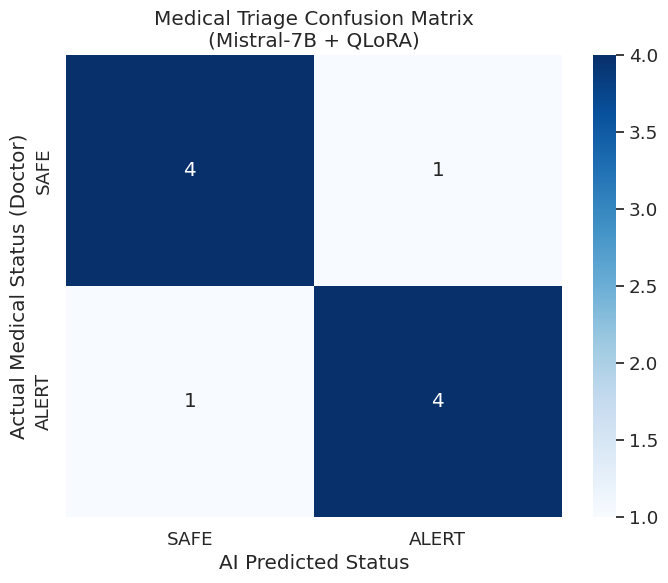

### Detailed Classification Report ###
              precision    recall  f1-score   support

        SAFE       0.80      0.80      0.80         5
       ALERT       0.80      0.80      0.80         5

    accuracy                           0.80        10
   macro avg       0.80      0.80      0.80        10
weighted avg       0.80      0.80      0.80        10

Overall Triage Accuracy: 80.00%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. Prepare your Test Data
# Based on your Table 6.1 (Safe vs Alert Scenarios)
# Mapping: 0 = SAFE, 1 = ALERT
y_actual = [0, 0, 1, 1, 0, 1, 1, 0, 0, 1]  # Doctor's Gold Standard
y_predicted = [0, 0, 1, 0, 0, 1, 1, 1, 0, 1] # AI Model's Triage Output

# 2. Generate the Confusion Matrix
cm = confusion_matrix(y_actual, y_predicted)
labels = ['SAFE', 'ALERT']

# 3. Visualization using Seaborn
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

plt.title('Medical Triage Confusion Matrix\n(Mistral-7B + QLoRA)')
plt.xlabel('AI Predicted Status')
plt.ylabel('Actual Medical Status (Doctor)')
plt.show()

# 4. Detailed Statistical Report
print("### Detailed Classification Report ###")
print(classification_report(y_actual, y_predicted, target_names=labels))
print(f"Overall Triage Accuracy: {accuracy_score(y_actual, y_predicted) * 100:.2f}%")